# FloraScan - ANN Baseline
Testing simple Artificial Neural Network (Dense layers only) for plant disease detection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## Configuration

In [2]:
TRAIN_DIR = r'd:\Florascann\dataset_limited\train'
TEST_DIR = r'd:\Florascann\dataset_limited\test'

IMG_SIZE = 64  # Smaller size for ANN
BATCH_SIZE = 32
EPOCHS = 10

NUM_CLASSES = len(os.listdir(TRAIN_DIR))
print(f"Classes: {NUM_CLASSES}")

Classes: 15


## Load Data

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 2221 images belonging to 15 classes.
Found 731 images belonging to 15 classes.


## Build ANN Model
Simple Dense layers - no convolutions. This is expected to perform poorly on image data.

In [4]:
model = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),  # Flatten image to 1D
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,180,815 (12.13 MB)

 Trainable params: 3,180,815 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [5]:
print("Training ANN model...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    verbose=1
)
print("Training completed!")

Training ANN model...
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.0716 - loss: 3.2754 - val_accuracy: 0.0684 - val_loss: 2.7069
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.0806 - loss: 2.6954 - val_accuracy: 0.0725 - val_loss: 2.6995
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.0707 - loss: 2.7051 - val_accuracy: 0.0807 - val_loss: 2.6878
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.0725 - loss: 2.7054 - val_accuracy: 0.0752 - val_loss: 2.6941
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.0657 - loss: 2.7022 - val_accuracy: 0.0752 - val_loss: 2.6913
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.0617 - loss: 2.7036 - val_accuracy: 0.0752 - val_loss: 2.6878
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.0716 - loss: 2.7004 - val_accuracy: 0.0752 - val_loss: 2.6875
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.0734 - loss: 2.7028 - v

## Results

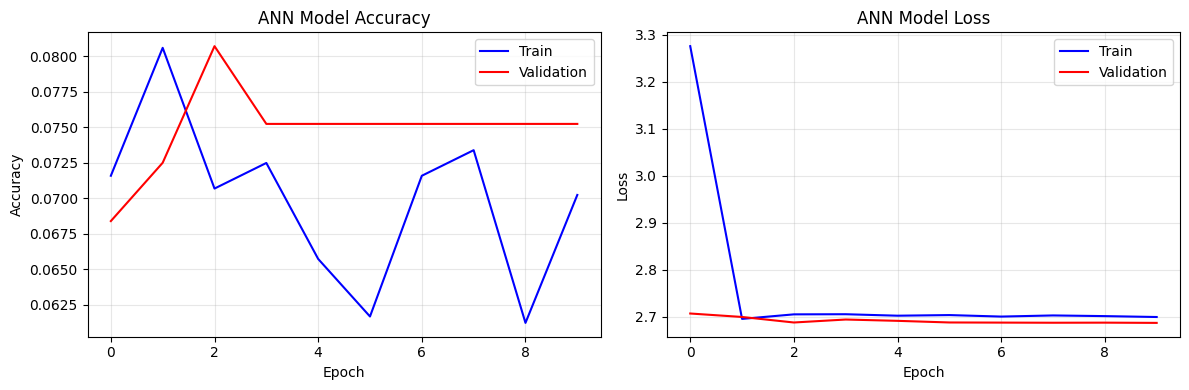

In [6]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], 'b-', label='Train')
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation')
axes[0].set_title('ANN Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-', label='Train')
axes[1].plot(history.history['val_loss'], 'r-', label='Validation')
axes[1].set_title('ANN Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Final evaluation
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

print("="*50)
print("ANN BASELINE RESULTS")
print("="*50)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {test_acc*100:.2f}%")
print("="*50)
print("\n⚠️ OBSERVATION: ANN performs poorly on image classification")
print("   Dense layers cannot capture spatial patterns in images.")
print("   → Need to try Convolutional Neural Networks (CNN)")

ANN BASELINE RESULTS
Final Training Accuracy: 7.02%
Final Validation Accuracy: 7.52%

⚠️ OBSERVATION: ANN performs poorly on image classification
   Dense layers cannot capture spatial patterns in images.
   → Need to try Convolutional Neural Networks (CNN)


In [8]:
# Save results for comparison
os.makedirs(r'd:\Florascann\results', exist_ok=True)
results = {
    'model': 'ANN Baseline',
    'train_acc': history.history['accuracy'][-1]*100,
    'val_acc': test_acc*100
}
print(f"\nModel: {results['model']}")
print(f"Validation Accuracy: {results['val_acc']:.2f}%")


Model: ANN Baseline
Validation Accuracy: 7.52%
